# 🎵 Warner Music Records — Spotify Hit Formula
### SQL + Python Mini-Project | Ironhack Data Analytics Bootcamp
**Team:** Claire & Diana &nbsp;|&nbsp; **Date:** May 2026 &nbsp;|&nbsp; **Dataset:** Kaggle Top 50 Spotify 2019

---

## 🏢 Business Context

**Warner Music Records (WMR)** commits A&R resources to new artists before those artists chart.  
The question is: _can audio features of already-charting songs reveal a pattern that helps WMR filter future investment decisions?_

---

## 🎯 Hypotheses

| | Hypothesis | Status |
|--|--|--|
| **H1** | Top 50 songs share a **universal** audio profile formula usable as a WMR investment filter | ✅ Partially Confirmed |
| **H2** | The hit formula **differs by genre**, requiring genre-specific investment criteria | ✅ Confirmed |

---

## 📋 Notebook Structure

| Section | Focus |
|--|--|
| **1. Setup & Data Loading** | Imports, raw data preview |
| **2. Data Quality & Cleaning** | Column renaming, type casting, null/duplicate checks |
| **3. Formula Analysis** | Universal hit formula baseline (H1): Genre ranking..etc |
| **4. Genre Analysis** | Popularity tiers, genre signatures (H2): Popularity, Tiers and testing formula H1 |
| **9. Conclusions & Recommendation** | WMR investment filter & recommendation |


---
## 1. Setup & Data Loading

In [36]:
#Importing libraries

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

sp_df=pd.read_csv('spotifytop50.csv')


# Code for making the first row as header. Remove if not needed.
#sp_df.columns = sp_df.iloc[0]
sp_df = sp_df.drop(columns=sp_df.columns[0])
sp_df.head()

print("✅ Libraries loaded")

✅ Libraries loaded


In [37]:
# ── Load raw CSV ─────────────────────────────────────────────────────────────
CSV_PATH = "spotifytop50.csv"

sp_df = pd.read_csv(CSV_PATH)
# Drop auto-generated index column if present
sp_df = sp_df.drop(columns=[c for c in sp_df.columns if "Unnamed" in str(c)])

print(f"Shape: {sp_df.shape}  ({sp_df.shape[0]} songs × {sp_df.shape[1]} features)")
sp_df.head(3)

Shape: (50, 13)  (50 songs × 13 features)


,Track.Name,Artist.Name,Genre,Beats.Per.Minute,Energy,Danceability,Loudness..dB..,Liveness,Valence.,Length.,Acousticness..,Speechiness.,Popularity
0,It's You,Ali Gatie,canadian hip hop,96,46,73,-7,19,40,213,37,3,89
1,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92
2,boyfriend (with Social House),Ariana Grande,dance pop,190,80,40,-4,16,70,186,12,46,85


---
## 2. Data Quality & Cleaning

### 2.1 Data Quality Audit

Before cleaning, we identify potential issues: messy column names, wrong data types, missing values, and duplicates.

In [38]:
# ── Column names (raw) 
sp_df.columns #get list to clean

Index(['Track.Name', 'Artist.Name', 'Genre', 'Beats.Per.Minute', 'Energy',
       'Danceability', 'Loudness..dB..', 'Liveness', 'Valence.', 'Length.',
       'Acousticness..', 'Speechiness.', 'Popularity'],
      dtype='object')

In [39]:
#Null counts & dtypes check
quality_report= pd.DataFrame({
    'dtype': sp_df.dtypes,
    'null_count': sp_df.isnull().sum(),
    'unique_vals': sp_df.nunique()})
print(quality_report)


                   dtype  null_count  unique_vals
Track.Name        object           0           50
Artist.Name       object           0           38
Genre             object           0           21
Beats.Per.Minute   int64           0           31
Energy             int64           0           31
Danceability       int64           0           29
Loudness..dB..     int64           0            9
Liveness           int64           0           22
Valence.           int64           0           39
Length.            int64           0           44
Acousticness..     int64           0           35
Speechiness.       int64           0           24
Popularity         int64           0           18


In [40]:
#Duplicate rows 
n_dupes = sp_df.duplicated().sum()
print(f"Duplicate rows detected: {n_dupes}")

#Duplicate track names 
col_track = ['Track.Name']
dupe_tracks = sp_df[col_track].duplicated(keep=False)
print(f"Songs with duplicate track names: {dupe_tracks.sum()}")


Duplicate rows detected: 0
Songs with duplicate track names: 0


### 2.2 Cleaning Strategy

| Issue | Strategy | Justification |
|--|--|--|
| Messy column names (dots, caps, trailing punctuation) | Standardise| Consistency for easy handling across Python|
| Numeric features stored as `object` | Cast via `pd.to_numeric` | Enables arithmetic and plotting |
| No missing values detected | No imputation needed | Data is complete |
| Duplicate track names (different versions) | Keep all rows | Each row is a distinct chart entry |

In [41]:
def clean_col_names(df):
    df2 = df.copy()
    df2.columns = df2.columns.map(lambda x: x.lower().replace('.','_'))
    df2 = df2.rename(columns={"loudness__db__": "loudness_db", "length_": "length","acousticness__": "acousticness", 'speechiness_':"speechiness","valence_":"valence"})
    return df2

def convert_numeric(df):
    df2 = df.copy()
    numeric_data = ['beats_per_minute', 'energy','danceability', 'loudness_db', 'liveness', 'valence', 'length','acousticness', 'speechiness', 'popularity']
    for i in numeric_data:
        df2[i] = pd.to_numeric(df2[i])
    return df2

sp_df = clean_col_names(sp_df)
sp_df = convert_numeric(sp_df)
print("✅ Cleaning complete")
print(f"Shape after cleaning: {sp_df.shape}")
sp_df.head(3)

✅ Cleaning complete
Shape after cleaning: (50, 13)


,track_name,artist_name,genre,beats_per_minute,energy,danceability,loudness_db,liveness,valence,length,acousticness,speechiness,popularity
0,It's You,Ali Gatie,canadian hip hop,96,46,73,-7,19,40,213,37,3,89
1,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92
2,boyfriend (with Social House),Ariana Grande,dance pop,190,80,40,-4,16,70,186,12,46,85


In [42]:
# ── Post-cleaning check ────────────────────────────────────────────────────────
print("Dtypes after cleaning:")
print(sp_df.dtypes)
print(f"\nNull values remaining: {sp_df.isnull().sum().sum()}")

Dtypes after cleaning:
track_name          object
artist_name         object
genre               object
beats_per_minute     int64
energy               int64
danceability         int64
loudness_db          int64
liveness             int64
valence              int64
length               int64
acousticness         int64
speechiness          int64
popularity           int64
dtype: object

Null values remaining: 0


---
## 3. Formula Analysis — H1: Universal Hit Formula Baseline

**H1 Question:** Do all Top 50 songs converge on a consistent audio profile?

We compute mean ± std for each audio feature. A **low std relative to mean** signals a strong, consistent signal — a candidate for the WMR filter.


In [43]:
#get standard deviations
numeric_data = ['beats_per_minute', 'energy','danceability', 'loudness_db', 'liveness', 'valence', 'length','acousticness', 'speechiness', 'popularity']
mean =[sp_df[i].astype(int).mean(axis=0) for i in numeric_data]
std = [sp_df[i].astype(int).std(axis=0) for i in numeric_data]
std_table = round(sp_df[numeric_data].describe().T[["mean", "std", "min", "max"]],2)


# Add coefficient of variation (std/mean) — lower = more consistent signal
# std_table["CV (%)"] = (desc["std"] / desc["mean"].abs() * 100).round(1)
std_table["CV (%)"] = (std_table["std"] / std_table["mean"].abs() * 100).round(1)
print(std_table)
print('__________')


                    mean    std    min    max  CV (%)
beats_per_minute  120.06  30.90   85.0  190.0    25.7
energy             64.06  14.23   32.0   88.0    22.2
danceability       71.38  11.93   29.0   90.0    16.7
loudness_db        -5.66   2.06  -11.0   -2.0    36.4
liveness           14.66  11.12    5.0   58.0    75.9
valence            54.60  22.34   10.0   95.0    40.9
length            200.96  39.14  115.0  309.0    19.5
acousticness       22.16  19.00    1.0   75.0    85.7
speechiness        12.48  11.16    3.0   46.0    89.4
popularity         87.50   4.49   70.0   95.0     5.1
__________


In [44]:
std_table.columns


Index(['mean', 'std', 'min', 'max', 'CV (%)'], dtype='object')

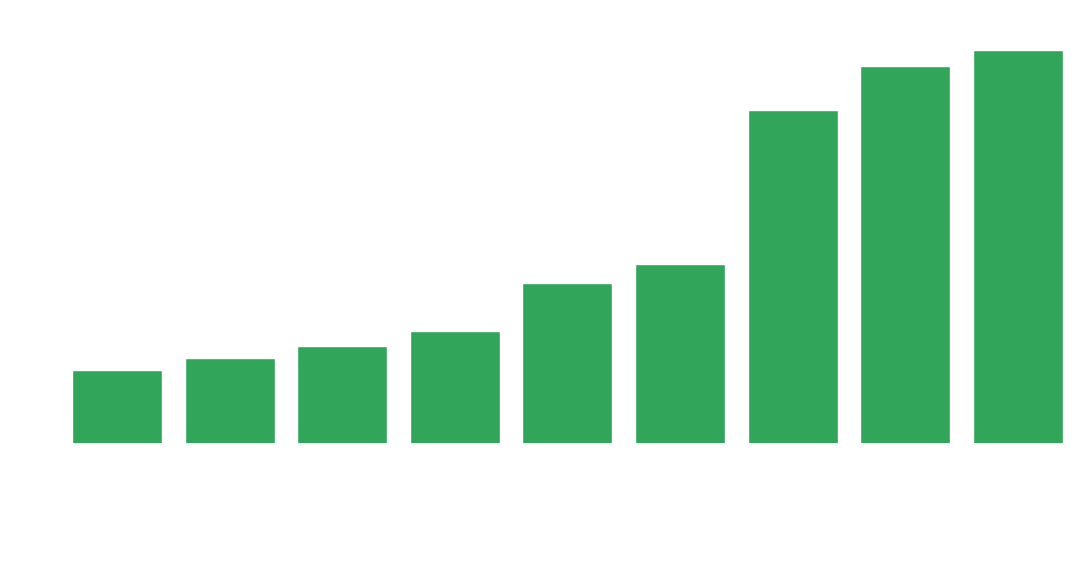

In [45]:
try:
    std_table = std_table.drop(index="popularity")
except:
    pass
std_table_sorted = std_table.sort_values('CV (%)', ascending=True)

# Create figure with dark-friendly settings
fig, ax = plt.subplots(figsize=(11, 6))

# Barplot (Spotify green)
sns.barplot(
    data=std_table_sorted,
    x=std_table_sorted.index,
    y='CV (%)',
    color="#1DB954",
    ax=ax
)

# Make background transparent (important for black slides)
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# Improve readability on dark background
ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")

# Rotate x labels for readability
plt.xticks(rotation=45, ha='right', color="white")

# Labels + title
ax.set_title("Coefficient of Variation by Audio Feature (Low → High)")
ax.set_xlabel("Feature")
ax.set_ylabel("CV (%)")

# Optional: subtle grid (helps on dark slides)
ax.grid(True, axis='y', alpha=0.2, color="white")

# Tight layout so labels don’t get cut off
plt.tight_layout()

# Save with transparency for Google Slides
plt.savefig(
    "cv_plot.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

**Interpretation:**
Here we look to the Coefficient of variation (std/mean) that tell us how big is the variation compared to the size of the average value.

- **Danceability** (mean 71, CV ~17%) and **Liveness** (mean 15, CV ~76%) emerge as the two most and least consistent features respectively.
- **BPM** has CV ~26% — moderate spread — suggesting WMR should NOT rely on tempo alone.

---
### 3.1 Genre Popularity Ranking

In [46]:
top10_genres = sp_df.genre.value_counts(ascending = False).head(10) #top_genres
top_10_genre_names = list(top10_genres.index)

filter_pop = []
filter_not = []
all_genres = list(sp_df.genre.unique())
for i in all_genres:
    if 'pop' in i:
      filter_pop.append(i)
    else:
      filter_not.append(i)

list_genres_ordered = filter_pop + filter_not


,acousticness,beats_per_minute,danceability,energy,length,liveness,loudness_db,popularity,speechiness,valence
genre,,,,,,,,,,
dance pop,27.000000,111.875000,70.250000,59.875000,202.625000,15.500000,-6.125000,85.750000,15.250000,45.875000
electropop,29.000000,135.000000,68.500000,44.000000,194.500000,11.000000,-11.000000,92.000000,34.000000,62.000000
pop,21.428571,114.142857,68.428571,63.285714,195.428571,12.142857,-6.285714,85.857143,9.285714,58.000000
pop house,4.000000,124.000000,68.000000,74.000000,153.000000,7.000000,-7.000000,91.000000,3.000000,63.000000
panamanian pop,10.500000,176.000000,74.000000,74.500000,257.000000,8.500000,-3.500000,89.000000,27.000000,69.000000
canadian pop,26.500000,120.500000,72.500000,68.500000,191.000000,10.500000,-5.000000,74.500000,4.500000,81.000000
australian pop,69.000000,98.000000,82.000000,59.000000,210.000000,18.000000,-6.000000,83.000000,10.000000,54.000000
canadian hip hop,21.666667,109.000000,80.000000,45.000000,193.000000,15.000000,-6.333333,89.666667,5.333333,33.333333
reggaeton flow,11.000000,98.500000,80.000000,80.000000,305.500000,8.500000,-4.000000,87.500000,8.000000,59.500000


<Axes: ylabel='genre'>

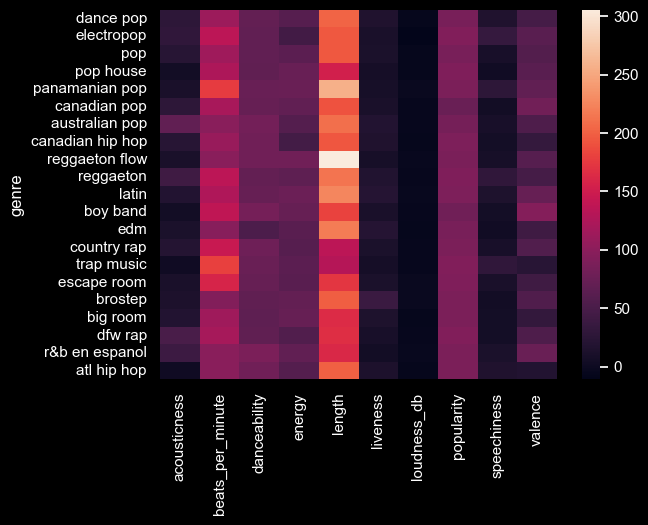

In [47]:
results = sp_df.pivot_table(index='genre',values= numeric_data, aggfunc='mean')
results = results.reindex(index=list_genres_ordered)
display(results)
sns.heatmap(results,annot=False)

# zscore_df=(results-results.min())/(results.max()-results.min())
# sns.heatmap(zscore_df, annot=False)
# results = sp_df.pivot_table(index='genre',values= numeric_data, aggfunc='mean')
# results = sp_df.pivot_table(index='genre',values= numeric_data, aggfunc='std')
# results = results.reindex(index=list_genres_ordered)
# sns.heatmap(results,annot=False)

C:\Users\clair\AppData\Local\Temp\ipykernel_516\2383998327.py:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  values_top_songs = binned_means_pivot_all.stack().head(10)


,acousticness,beats_per_minute,danceability,energy,length,liveness,loudness_db,popularity,speechiness,valence
rank,,,,,,,,,,
0.0,29.6,149.2,68.6,63.0,210.6,12.0,-6.0,93.2,22.8,36.4
1.0,19.0,125.8,74.6,64.6,182.4,17.4,-4.8,91.2,6.2,48.4
2.0,22.2,129.4,69.6,67.4,204.4,8.6,-5.0,90.6,17.2,59.4
3.0,16.0,97.8,74.8,63.2,184.8,12.4,-6.4,89.2,11.4,46.2
4.0,26.0,128.8,70.6,63.8,204.4,19.4,-7.0,88.8,20.0,62.8
5.0,31.4,109.2,70.0,57.4,190.2,16.2,-6.2,88.0,5.8,52.0
6.0,10.2,130.4,73.6,72.8,200.6,25.6,-3.6,87.4,9.0,68.4
7.0,19.6,115.4,64.6,64.6,201.0,14.2,-5.4,85.6,15.8,55.8
8.0,22.4,100.8,70.4,54.8,237.6,11.8,-6.8,83.2,9.8,39.4


                        mean  max  min
rank                                  
0.0  acousticness       29.6   60    2
     beats_per_minute  149.2  180  105
     danceability       68.6   79   58
     energy             63.0   81   43
     length            210.6  302  131
     liveness           12.0   24    7
     loudness_db        -6.0   -4  -11
     popularity         93.2   95   92
     speechiness        22.8   38    7
     valence            36.4   61   18


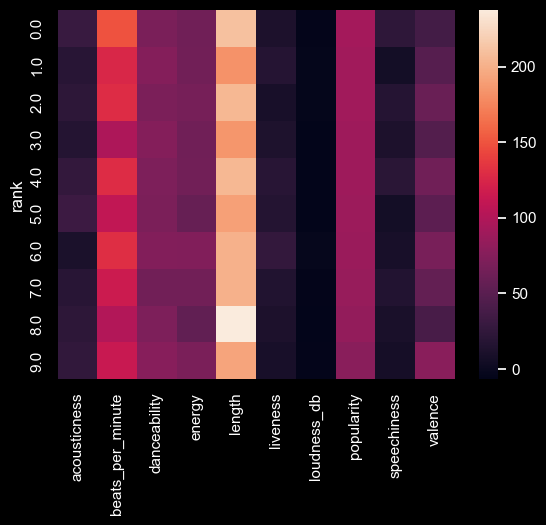

In [48]:
means_binned_by_5 =  sp_df.sort_values('popularity', ascending=False)
means_binned_by_5['rank'] = [np.floor(n/5) for n in range(50)]

binned_means_pivot = means_binned_by_5.pivot_table(index='rank',values=numeric_data,aggfunc='mean')
binned_means_pivot_all = means_binned_by_5.pivot_table(index='rank',values=numeric_data,aggfunc=['mean','max','min'])

values_top_songs = binned_means_pivot_all.stack().head(10)

sns.heatmap(binned_means_pivot,annot=False)
display(binned_means_pivot)
print(values_top_songs)

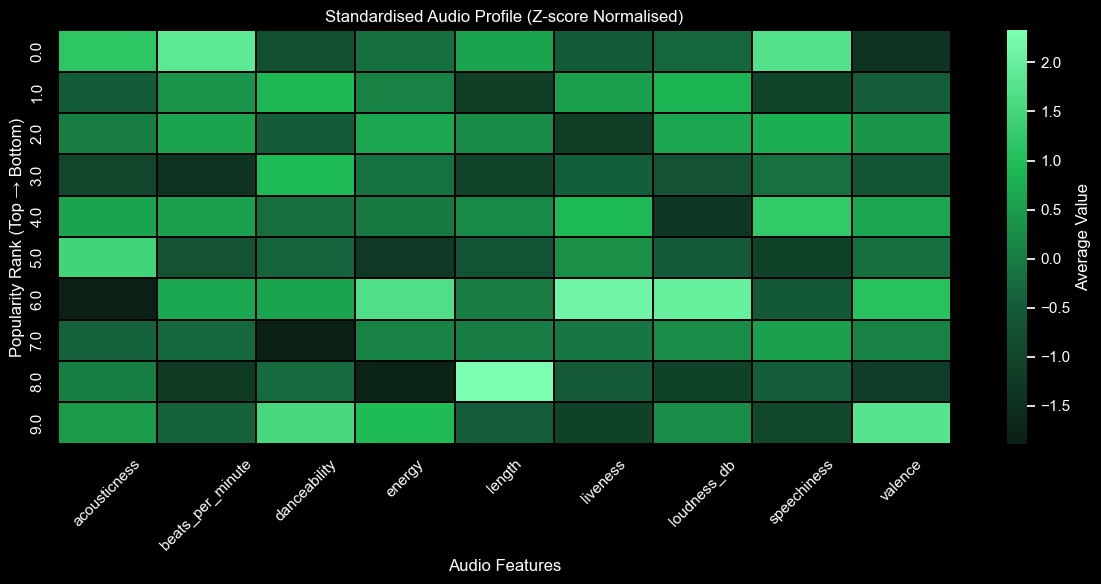

In [62]:
from matplotlib.colors import LinearSegmentedColormap

pivot_no_popularity = binned_means_pivot.copy()

pivot_no_popularity = pivot_no_popularity.drop(columns="popularity")
pivot_norm = (pivot_no_popularity - pivot_no_popularity.mean()) / pivot_no_popularity.std()


# Spotify-style dark theme
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(12, 6))
spotify_cmap = LinearSegmentedColormap.from_list(
    "spotify_green",
    ["#0b1f14", "#145c3a", "#1DB954", "#7CFFB2"]
)

sns.heatmap(
    pivot_norm,  # your data
    cmap=spotify_cmap,  # Spotify-like green scale
    linewidths=0.3,
    linecolor="black",
    cbar_kws={"label": "Average Value"},
    ax=ax
)

# Axis labels
ax.set_xlabel("Audio Features", color="white")
ax.set_ylabel("Popularity Rank (Top → Bottom)", color="white")
ax.set_title("Standardised Audio Profile (Z-score Normalised)", color="white")

# Tick styling
ax.tick_params(axis='x', colors='white', rotation=45)
ax.tick_params(axis='y', colors='white')

# Improve colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color("white")
cbar.ax.tick_params(colors="white")

plt.tight_layout()

plt.savefig(
    "heatmap.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

beats_per_minute    141.166667
energy               60.833333
danceability         71.000000
loudness_db          -5.666667
liveness             12.000000
valence              32.000000
length              209.666667
acousticness         26.333333
speechiness          19.833333
popularity           93.000000
dtype: float64

beats_per_minute    110.333333
energy               65.000000
danceability         75.833333
loudness_db          -5.666667
liveness             10.166667
valence              66.666667
length              204.833333
acousticness         23.000000
speechiness           8.166667
popularity           78.500000
dtype: float64

<Axes: >

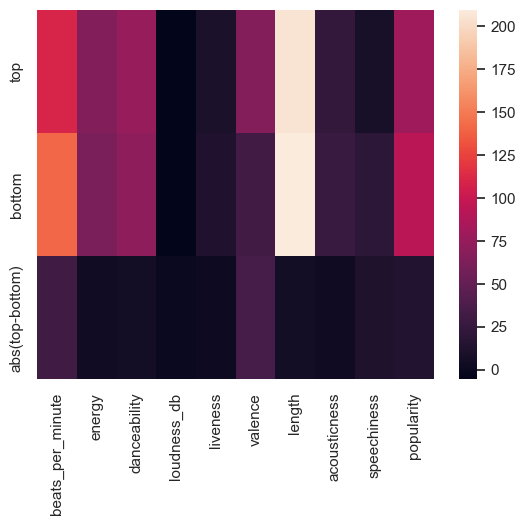

In [28]:
#Sorting the data by the ranking to be able to see a better relationship

sorted_top= sp_df.sort_values('popularity', ascending=False)
sorted_top=sorted_top.iloc[:6,:]
# display(sorted_top)
# sns.heatmap(sorted_top.loc[:,numeric_data],annot=False)


display(sorted_top.mean(numeric_only=True))

sorted_bottom= sp_df.sort_values('popularity', ascending=True)
sorted_bottom=sorted_bottom.iloc[:6,:]
# display(sorted_bottom)
# sns.heatmap(sorted_bottom.loc[:,numeric_data],annot=False)


display(sorted_bottom.mean(numeric_only=True))
bottom_means = sorted_bottom.mean(numeric_only=True)
sns.heatmap([sorted_bottom.mean(numeric_only=True), sorted_top.mean(numeric_only=True),abs(sorted_bottom.mean(numeric_only=True)-
                                                                                           sorted_top.mean(numeric_only=True))],annot=False,xticklabels=numeric_data,yticklabels=['top','bottom','abs(top-bottom)'])


,track_name,artist_name,genre,beats_per_minute,energy,danceability,loudness_db,liveness,valence,length,acousticness,speechiness,popularity
43,If I Can't Have You,Shawn Mendes,canadian pop,124,82,69,-4,13,87,191,49,6,70
23,"fuck, i'm lonely (with Anne-Marie) - from “13 ...",Lauv,dance pop,95,56,81,-6,6,68,199,48,7,78
42,Señorita,Shawn Mendes,canadian pop,117,55,76,-6,8,75,191,4,3,79
18,Sucker,Jonas Brothers,boy band,138,73,84,-5,11,95,181,4,6,80
7,No Guidance (feat. Drake),Chris Brown,dance pop,93,45,70,-7,16,14,261,12,15,82
14,Cross Me (feat. Chance the Rapper & PnB Rock),Ed Sheeran,pop,95,79,75,-6,7,61,206,21,12,82


<Axes: >

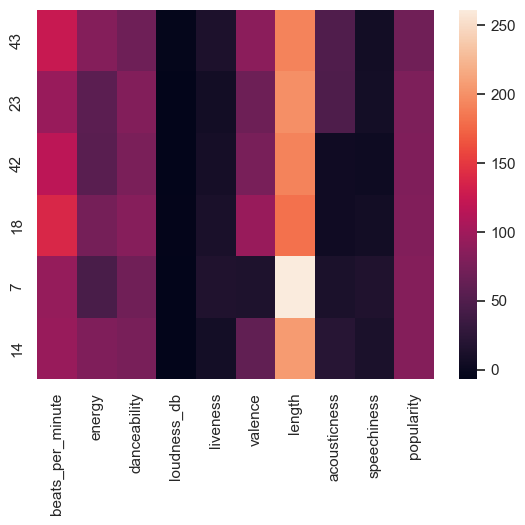

In [29]:
sorted= sp_df.sort_values('popularity', ascending=True)
sorted=sorted.iloc[:6,:]
# display(sorted.pivot_table(index='track_name', columns=numeric_data, aggfunc='mean'))
display(sorted)
sns.heatmap(sorted.loc[:,numeric_data],annot=False)

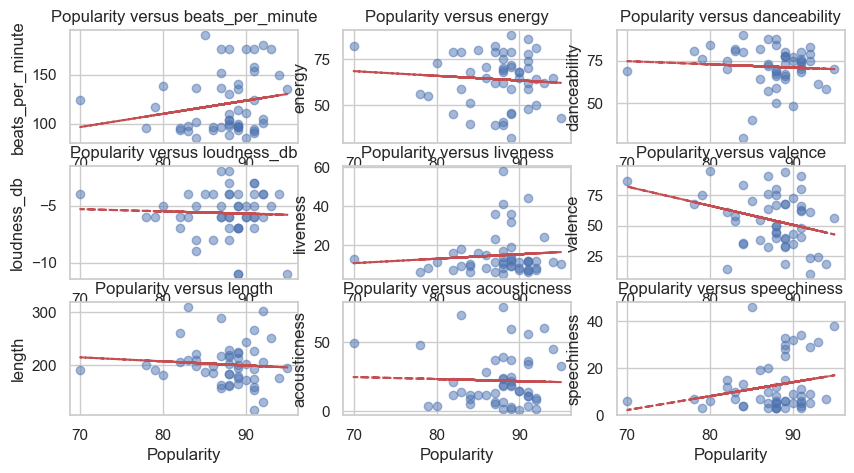

In [69]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
for_scatter = numeric_data
# for_scatter.remove('popularity')
for i in range(len(for_scatter)-1):
    plt.subplot(3, 3, i+1)
    plt.scatter(sp_df.popularity,sp_df[for_scatter[i]], alpha=0.5)
    plt.title(f"Popularity versus {for_scatter[i]}")
    plt.xlabel('Popularity')
    plt.ylabel(f"{for_scatter[i]}")
    x= sp_df.popularity
    y= sp_df[for_scatter[i]]
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x,p(x),"r--")

<Axes: >

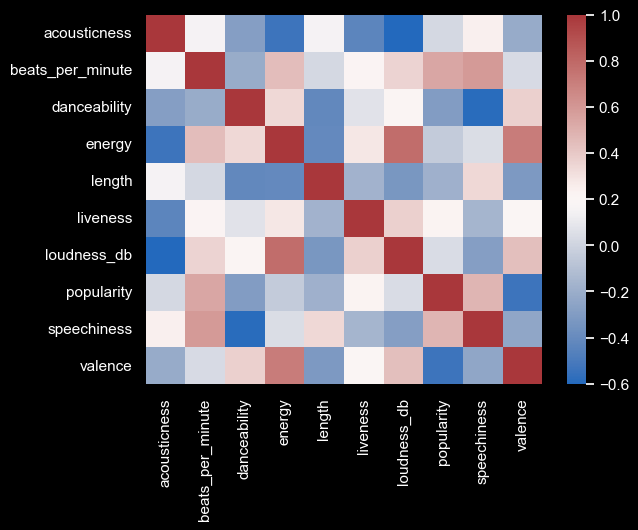

In [63]:
# mat=sp_df[numeric_data].corr(method='pearson')
# sns.heatmap(mat,annot=False,cmap="vlag")
spotify_corr = LinearSegmentedColormap.from_list(
    "spotify_corr",
    ["#2C3E50", "white", "#1DB954"]
)
cross_corr_mat=binned_means_pivot.corr(method='pearson')
sns.heatmap(cross_corr_mat,annot=False,cmap="vlag")

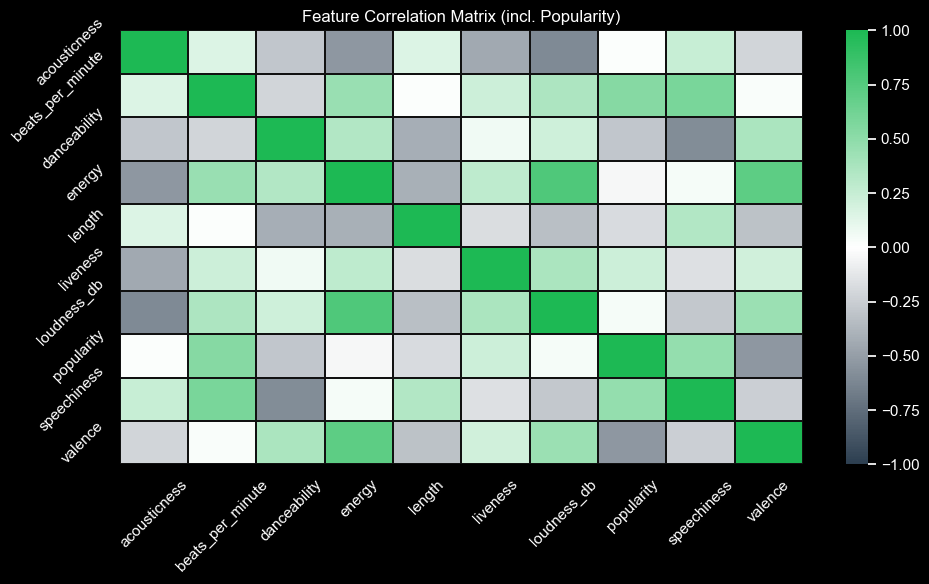

In [64]:
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    cross_corr_mat,
    cmap=spotify_corr,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor="#111",
    ax=ax
)

ax.set_title("Feature Correlation Matrix (incl. Popularity)", color="white")
ax.tick_params(colors="white", rotation=45)

plt.tight_layout()
plt.show()

---
## 4. Genre Analysis — H2: Genre-Specific Formula

**H2 Question:** Do different genres have meaningfully different audio profiles?

### 4.1 Popularity by Genre

In [22]:
#Analysis on Genre, to see what are those making the top list and the artist in them.

print(f"The number of genres are: {sp_df.genre.nunique()}")
# Creating Genre pivot table: genres as columns, avg popularity as value
genre_popularity = (
    sp_df.groupby("genre")["popularity"]
    .mean()
    .round(1)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"popularity": "avg_popularity"})
)
genre_popularity

The number of genres are: 21


,genre,avg_popularity
0,dfw rap,92.5
1,trap music,92.0
2,electropop,92.0
3,reggaeton,91.0
4,pop house,91.0
5,escape room,91.0
6,latin,89.8
7,canadian hip hop,89.7
8,panamanian pop,89.0
9,atl hip hop,89.0


/var/folders/y7/p6n8z7nn4fs88vn9n57nxbh40000gn/T/ipykernel_8471/1146175612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


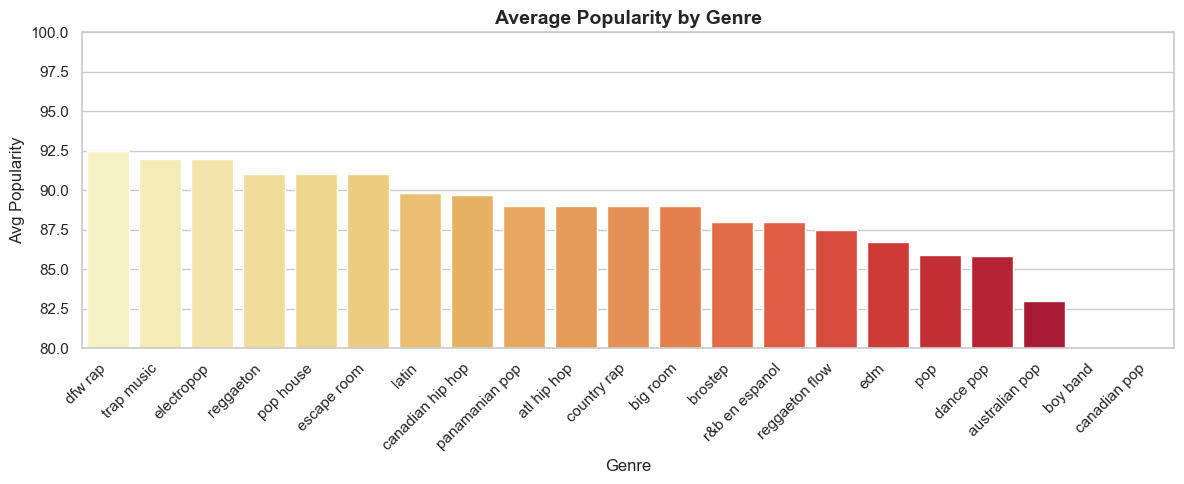

In [34]:
#To visually identify how to group the Genres given their popularity rating
plt.figure(figsize=(12, 5))
sns.barplot(
    data=genre_popularity,
    x="genre",
    y="avg_popularity",
    palette="YlOrRd",
    order=genre_popularity["genre"]  # already sorted desc
)
plt.title("Average Popularity by Genre", fontsize=14, fontweight="bold")
plt.xlabel("Genre")
plt.ylabel("Avg Popularity")
plt.xticks(rotation=45, ha="right")
plt.ylim(80, 100)  # zoom in — all Top 50 songs cluster high
plt.tight_layout()
plt.savefig("barplot_popularity_by_genre.png", dpi=150)
plt.show()

### 4.2 Genre Popularity Tiers

From the bar chart we identify **three natural tiers**:

| Tier | Genres | Avg Popularity |
|--|--|--|
| **Elite** | DFW Rap, Trap, Electropop | ≥ 92 |
| **Mid-High** | Latin, Reggaeton, Pop House, Escape Room, Canadian Hip-Hop, Reggaeton Flow, Panamanian Pop, ATL Hip-Hop, Country Rap, Big Room | 88–91 |
| **Solid** | Brostep, R&B en Español, EDM, Pop, Dance Pop, Australian Pop, Boy Band, Canadian Pop | 74–88 |

In [35]:
#from the graph we can distinguish in 3 categories:
#cat_1: lowest popularity genres group from candian pop to brostep
#cat_2: middle popularity genre group from brostep to latin
#cat_3: highest popularity genres group from latin to dfw rap

print(genre_popularity[genre_popularity['genre'].isin(['brostep','latin','dfw'])]) #here we see the popularity rating corresponding to the genres,which divides the data in those groups

      genre  avg_popularity
6     latin            89.8
12  brostep            88.0


In [36]:
#New column category
sp_df['category'] = None

# Assigning integers based on your rules
sp_df.loc[sp_df['popularity'] < 88, 'category'] = 1
sp_df.loc[sp_df['popularity'].between(88, 89), 'category'] = 2
sp_df.loc[sp_df['popularity'] > 89, 'category'] = 3

# Optional: Convert the column to integer type if needed
sp_df['category'] = sp_df['category'].astype(int)
sp_df.head(2)

,track_name,artist_name,genre,beats_per_minute,energy,danceability,loudness_db,liveness,valence,length,acousticness,speechiness,popularity,category
0,It's You,Ali Gatie,canadian hip hop,96,46,73,-7,19,40,213,37,3,89,2
1,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92,3


In [37]:
# Now, we group by category and artist to count the number of tracks
song_counts = sp_df.groupby(['category', 'artist_name']).size().reset_index(name='count')

#For each category, find the index of the row with the maximum count
idx_of_max = song_counts.groupby('category')['count'].idxmax()

#Pulling those specific rows out
top_artists_df = song_counts.loc[idx_of_max]

print(top_artists_df)

    category  artist_name  count
3          1   Ed Sheeran      4
22         2   Marshmello      2
40         3  Post Malone      2


In [ ]:
#Now the idea will be to check how close the songs from the top Artist (category 3, Post Malone) are to the mean 
#from the top ranking before, per metric. Then, do the same for the songs from the common artist in category 1. To see if the
#songs from the cat3 are closer to the mean metric than the ones from cat1. 

---
### 4.3 Testing formula across Tiers

TBD


---
## 5. Conclusions & WMR Investment Recommendation

### H1 — Universal Formula: **Partially Confirmed** ✅

The Top 50 songs share a **consistent baseline profile** across most audio features. The universal filter below captures the typical hit:

```
Danceability  ≥ X
Energy        ≥ X
Loudness      ≥ X dB    (not too quiet / compressed)
Liveness      ≤ X         (studio / polished production)
Acousticness  ≤ X
```

**Limitation:** BPM and Valence have high variance (CV > 25%), so they should NOT be fixed in the universal filter.

---

### H2 — Genre-Specific Formula: **Confirmed** ✅

TBD: Genre-specific audio profiles differ or not meaningfully. Add these on top of the universal filter:

| Genre cluster | Additional criteria |
|--|--|
| Genres x | Valence ≥ x · BPM x–x |
| Genres | Drop valence constraint · Speechiness x-x |
| Genres | Danceability ≥ x · Energy ≥ x0 |

---

### 🛑 Limitations

1. **Small sample** (50 songs) — descriptive only; no causal inference possible.
2. **No control group** — without non-charting songs, we can't isolate *what makes* a hit.
3. **Single year (2019)** — genre trends shift; these thresholds may not generalise.
